## Financial Data: Essential Workflows

### Exercise 12: Financial Time Series

Import the us stocks dataset (__us_stocks.csv__) and select the Adjusted Close (__Adj Close__) for all six stocks from __01-01-2026__ (incl.) until __01-08-2026__ (incl.). Save the DataFrame in the variable __stocks__ and work through the next questions with this DataFrame!

- __Visualize__ the Adjusted Close of the six stocks __over time__!

- __Visualize__ the __normalized__ Adjusted Close of the six stocks __over time__, each starting at a __Base Value of 100__!

- Calculate __monthly returns__ for all six stocks and create a new __returns__ DataFrame!

- Calculate the __annualized mean return__ and the __annualized standard deviation__ of returns for all six stocks!

- __Visualize risk/return__ of all six stocks in a (total) risk / return framework. (annualized std on the x-axis, annualized mean returns on the y-axis). <br>
Identify the __best performing__ stock and the __worst performing__ stock (in terms of __risk / return__)

- __Visualize__ the __correlation matrix__ of monthly returns with a __Seaborn Heatmap__. Which stocks-pair shows the __highest (positive) correlation__ of monthly returns?

__Ticker Symbols__:
- AXP : American Express
- FB : Facebook
- INTC : Intel
- MCD : McDonalds
- PG : Procter & Gamble
- WMT: Walmart

------------------------

In [ ]:
# Install yfinance to download stock data
!pip install yfinance

# Extract Data

In [1]:
# Initial Libraries
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

# Define tickers
tickers = ["AXP", "META", "INTC", "MCD", "PG", "WMT"]

# Define Start and end date
start_date = "2021-01-01"
end_date = "2026-01-08"  # Exclusive in yfinance

# Download the data
stocks = yf.download(
    tickers,
    start=start_date,
    end=end_date,
    auto_adjust=False,
    progress=False
)

# Inspect the data
stocks.head()

Price        Adj Close                                                 \
Ticker             AXP       INTC         MCD        META          PG   
Date                                                                    
2021-01-04  110.072418  44.902931  185.239365  266.598816  118.965569   
2021-01-05  110.659882  45.752716  186.349640  268.611176  119.725151   
2021-01-06  114.753548  46.195698  185.926697  261.017914  120.985435   
2021-01-07  113.845856  47.181076  186.790253  266.400604  119.854637   
2021-01-08  113.958160  46.692902  190.217987  265.240814  119.802826   

Price                       Close                                     ...  \
Ticker            WMT         AXP       INTC         MCD        META  ...   
Date                                                                  ...   
2021-01-04  45.454304  118.040001  49.669998  210.220001  268.940002  ...   
2021-01-05  45.212353  118.669998  50.610001  211.479996  270.970001  ...   
2021-01-06  45.494629  123.059998  51.099998  211.000000  263.309998  ...   
2021-01-07  45.491531  121.660004  52.189999  211.979996  268.739990  ...   
2021-01-08  45.485329  121.779999  51.650002  215.869995  267.570007  ...   

Price             Open                                      Volume            \
Ticker             MCD        META          PG        WMT      AXP      INTC   
Date                                                                           
2021-01-04  214.490005  274.779999  139.660004  48.099998  3472100  46102500   
2021-01-05  210.179993  268.290009  137.990005  48.866669  2112700  24866600   
2021-01-06  211.300003  262.000000  138.770004  48.363335  5861500  36809600   
2021-01-07  213.220001  265.899994  139.750000  49.206669  8696600  32092300   
2021-01-08  212.899994  268.309998  138.470001  48.959999  2934500  34625400   

Price                                              
Ticker          MCD      META        PG       WMT  
Date                                               
2021-01-04  4055400  15106100   8330900  32182200  
2021-01-05  2576100   9871600   6856400  26498100  
2021-01-06  3083400  24354100  10578000  21918900  
2021-01-07  3142000  15789800   7355400  20538000  
2021-01-08  2639100  18528300   7448500  24478200  

[5 rows x 36 columns]

# Extract and visualize Adjusted Close prices

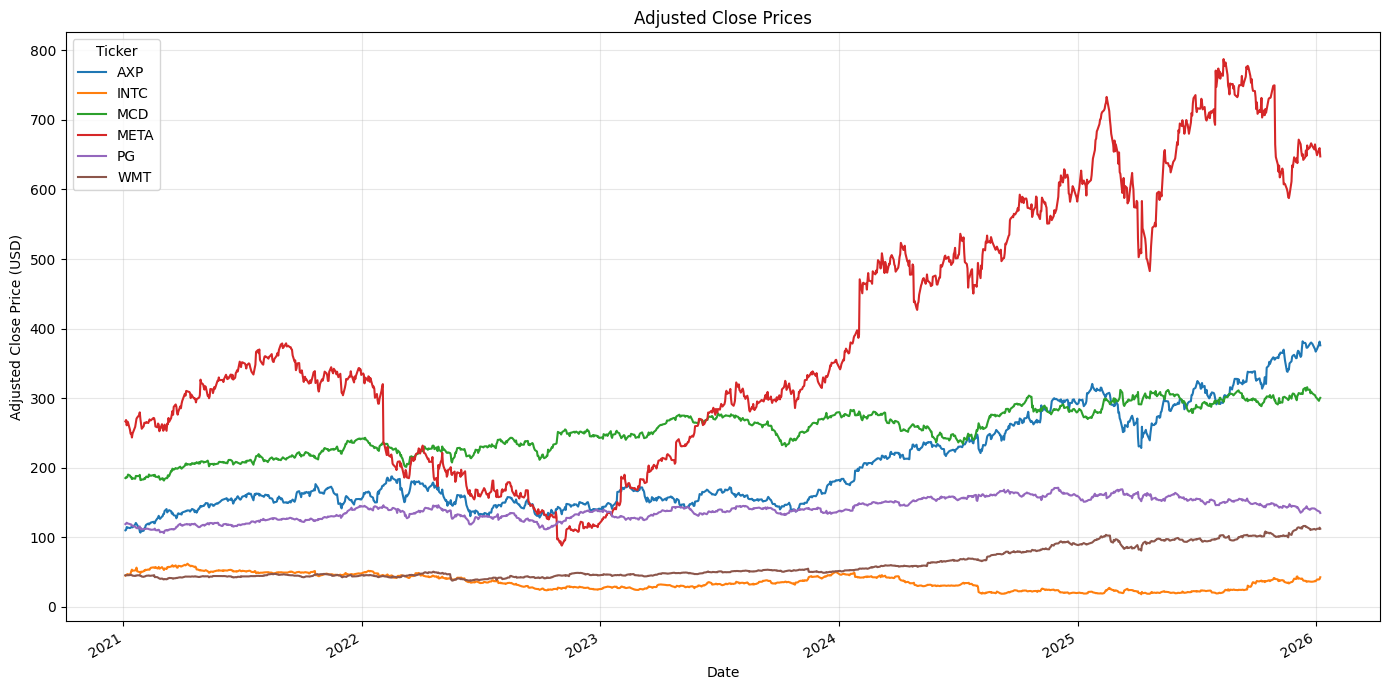

In [ ]:
adjusted_close = stocks["Adj Close"].copy()

adjusted_close = adjusted_close.dropna(how="all")

adjusted_close.plot(
    figsize=(14, 7),
    linewidth=1.5,
    title="Adjusted Close Prices"
)

plt.xlabel("Date")
plt.ylabel("Adjusted Close Price (USD)")
plt.legend(title="Ticker")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Normalize Adjusted Close prices to a base value of 100

Normalization allows stocks with different price levels to be compared on the same scale.

Example: A value of 120 means the investment increased by 20% from its starting value.

In [ ]:
normalized_prices = adjusted_close.div(
    adjusted_close.iloc[0]
).mul(100)

In [ ]:
normalized_prices.describe()

Ticker,AXP,INTC,MCD,META,PG,WMT
count,1259.000000,1259.000000,1259.000000,1259.000000,1259.000000,1259.000000
mean,183.340668,79.253754,136.765041,145.009892,117.605880,134.409109
std,62.426634,24.456378,17.998729,70.027951,12.438058,48.284115
min,96.992586,40.375971,98.040305,33.059413,89.164705,82.627711
25%,136.245092,57.477750,122.267213,88.281756,107.797243,98.405834
50%,151.253177,76.511815,136.011370,124.373448,117.511961,109.894404
75%,231.684786,100.127763,151.119886,200.897765,128.057126,174.331954
max,346.845844,138.261183,170.445876,295.357279,143.959781,255.924692


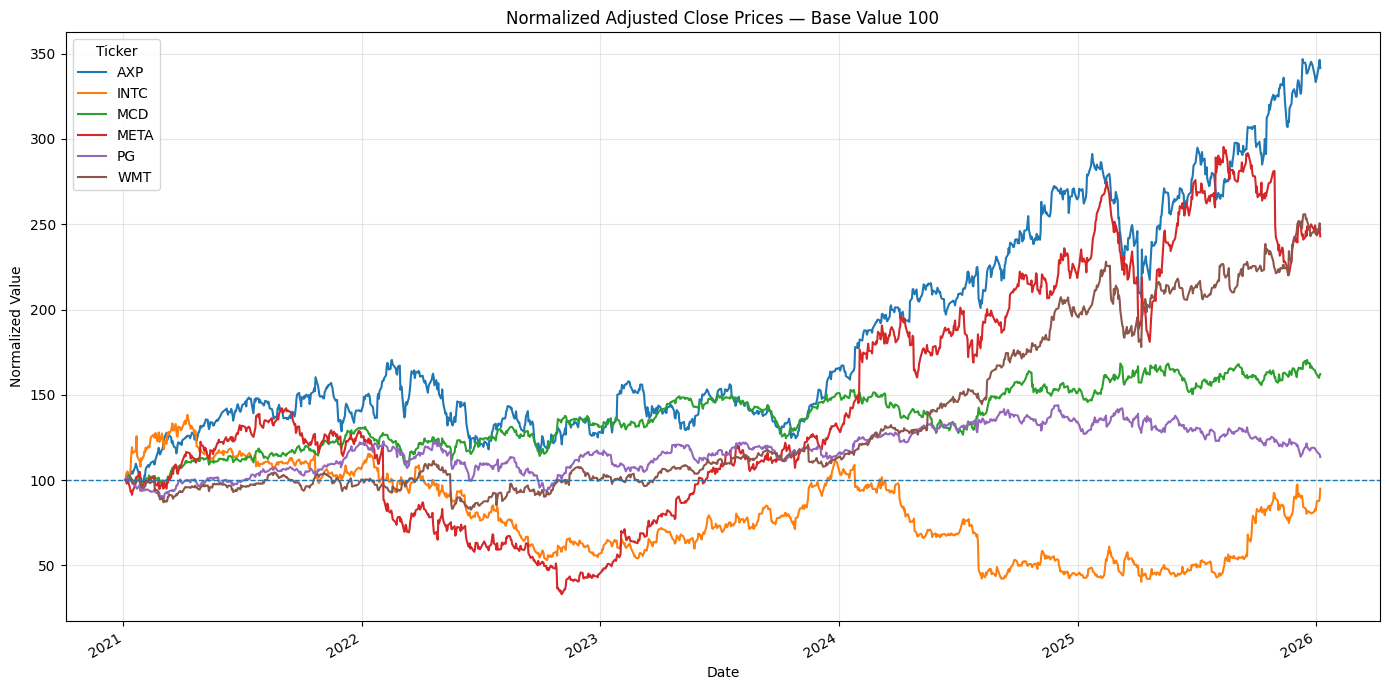

In [ ]:
normalized_prices.plot(
    figsize=(14, 7),
    linewidth=1.5,
    title="Normalized Adjusted Close Prices — Base Value 100"
)

plt.axhline(100, linestyle="--", linewidth=1)
plt.xlabel("Date")
plt.ylabel("Normalized Value")
plt.legend(title="Ticker")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate monthly returns

- The final adjusted closing price of each month is used. Monthly returns are then calculated as percentage changes between consecutive month-end prices.

In [ ]:
monthly_prices = adjusted_close.resample("ME").last()

In [ ]:
monthly_returns = monthly_prices.pct_change(
    fill_method=None
).dropna(how="all")

In [ ]:
monthly_prices.head()

Ticker,AXP,INTC,MCD,META,PG,WMT
Date,,,,,,
2021-01-31,108.792709,50.182438,183.142197,256.081207,111.337776,43.580677
2021-02-28,126.572342,55.280186,182.761887,255.377380,107.273666,40.301807
2021-03-31,132.753235,58.208809,198.720459,291.966095,117.607643,42.311035
2021-04-30,143.931778,52.324261,209.306366,322.250061,116.603416,43.581959
2021-05-31,150.295349,52.271339,208.510010,325.868347,117.853203,44.416088


In [ ]:
print("Monthly returns DataFrame shape:", monthly_returns.shape)
display(monthly_returns.tail())

Monthly returns DataFrame shape: (60, 6)


Ticker,AXP,INTC,MCD,META,PG,WMT
Date,,,,,,
2025-09-30,0.002656,0.377823,-0.025275,-0.005177,-0.021587,0.062693
2025-10-31,0.088765,0.191952,-0.017967,-0.117147,-0.014504,-0.018242
2025-11-30,0.012585,0.014254,0.044868,-0.000617,-0.014697,0.092212
2025-12-31,0.012813,-0.090237,-0.013969,0.019567,-0.032735,0.010199
2026-01-31,0.024625,0.155285,-0.004810,-0.017270,-0.036773,0.011758


# Calculate annualized mean return and annualized risk

- Because the data contains monthly returns:
- Annualized mean return = monthly mean × 12
- Annualized standard deviation = monthly standard deviation × √12

In [ ]:
annualized_mean_return = monthly_returns.mean() * 12

In [ ]:
annualized_std = monthly_returns.std() * np.sqrt(12)

In [ ]:
risk_return_summary = pd.DataFrame({
    "annualized_mean_return": annualized_mean_return,
    "annualized_std": annualized_std
})

In [ ]:
risk_return_summary["return_to_risk"] = (
    risk_return_summary["annualized_mean_return"]
    / risk_return_summary["annualized_std"]
)

In [ ]:
risk_return_summary = risk_return_summary.sort_values(
    "return_to_risk",
    ascending=False
)

In [ ]:
risk_return_summary


,annualized_mean_return,annualized_std,return_to_risk
Ticker,,,
AXP,0.283495,0.259821,1.091116
WMT,0.209541,0.195482,1.071922
MCD,0.112174,0.163794,0.684849
META,0.272836,0.409585,0.666127
PG,0.053063,0.172471,0.307662
INTC,0.063051,0.442925,0.142350


# Visualize the total-risk/return framework

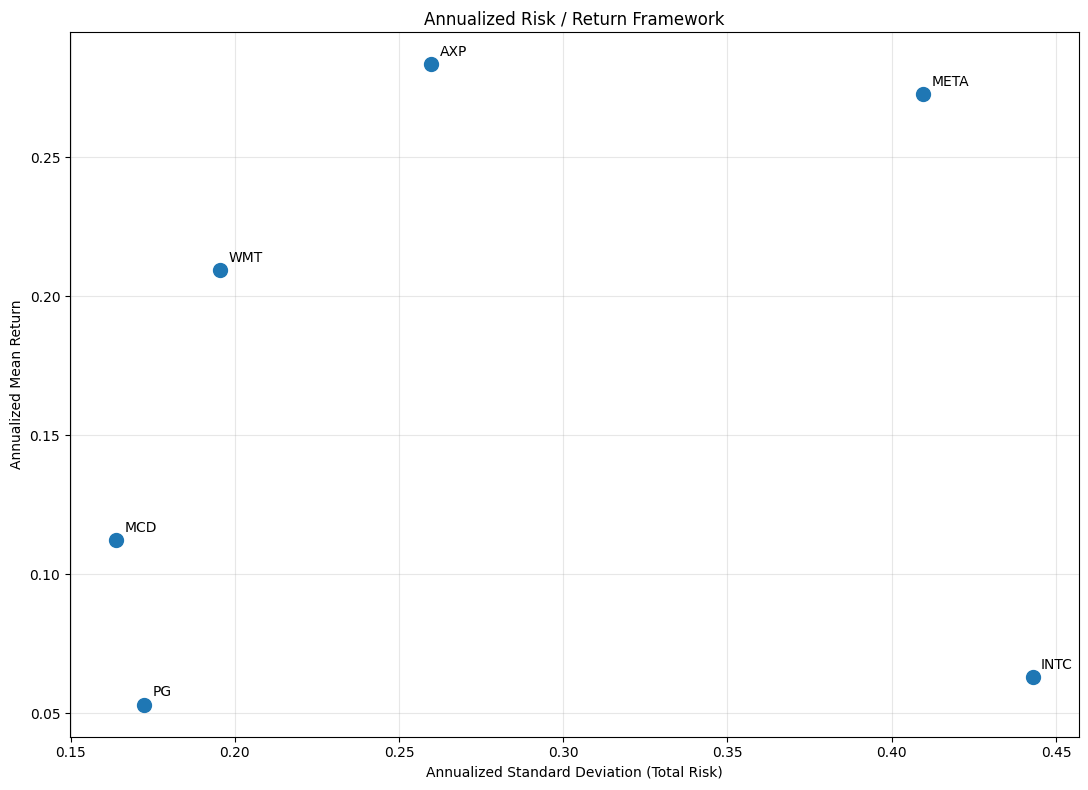

In [ ]:
fig, ax = plt.subplots(figsize=(11, 8))

ax.scatter(
    risk_return_summary["annualized_std"],
    risk_return_summary["annualized_mean_return"],
    s=100
)

for ticker, row in risk_return_summary.iterrows():
    ax.annotate(
        ticker,
        (
            row["annualized_std"],
            row["annualized_mean_return"]
        ),
        xytext=(6, 6),
        textcoords="offset points"
    )

ax.set_title("Annualized Risk / Return Framework")
ax.set_xlabel("Annualized Standard Deviation (Total Risk)")
ax.set_ylabel("Annualized Mean Return")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Identify the best and worst performers

- For this the performance is assessed using the return-to-risk ratio:
- annualized mean return ÷ annualized standard deviation.
- This is a simplified risk-adjusted measure and does not subtract a risk-free rate.

In [ ]:
best_stock = risk_return_summary["return_to_risk"].idxmax()
worst_stock = risk_return_summary["return_to_risk"].idxmin()

In [ ]:
print("Best risk-adjusted performer:", best_stock)
print(
    risk_return_summary.loc[
        best_stock,
        ["annualized_mean_return", "annualized_std", "return_to_risk"]
    ]
)

Best risk-adjusted performer: AXP
annualized_mean_return    0.283495
annualized_std            0.259821
return_to_risk            1.091116
Name: AXP, dtype: float64


In [ ]:
print("\nWorst risk-adjusted performer:", worst_stock)
print(
    risk_return_summary.loc[
        worst_stock,
        ["annualized_mean_return", "annualized_std", "return_to_risk"]
    ]
)


Worst risk-adjusted performer: INTC
annualized_mean_return    0.063051
annualized_std            0.442925
return_to_risk            0.142350
Name: INTC, dtype: float64


# Correlation matrix of monthly returns

In [ ]:
correlation_matrix = monthly_returns.corr()

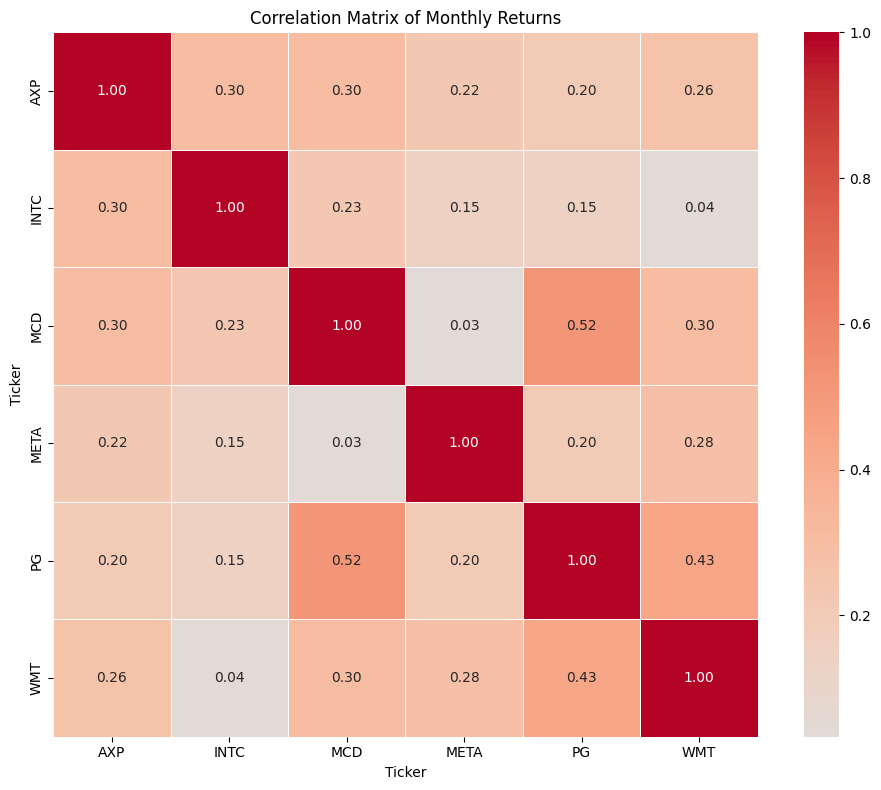

In [ ]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)

plt.title("Correlation Matrix of Monthly Returns")
plt.tight_layout()
plt.show()